In [52]:
# ============================================================
# CELL 1 - Install
# ============================================================
!pip install ultralytics transformers -q

In [53]:
# ============================================================
# CELL 2 - Imports
# ============================================================
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont
from transformers import CLIPProcessor, CLIPModel
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
from google.colab import drive
import colorsys, math, os, json
from collections import defaultdict
from IPython.display import display, clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [74]:
# ============================================================
# CELL 3 - Config (tune everything here)
# ============================================================
CONFIG = {
    # ── paths ──────────────────────────────────────────────
    "model_path" : "/kaggle/input/datasets/astitwarajawat/yolo-model/best.pt",
    "video_path" : "/kaggle/input/datasets/astitwarajawat/demo-videos/20260426_201443_1.mp4",

    # ── frame extraction ───────────────────────────────────
    "frame_interval_sec" : 1,       # extract one frame every N seconds

    # ── detection ──────────────────────────────────────────
    "conf"        : 0.25,
    "iou"         : 0.45,
    "min_box_size": 20,

    # ── human / obstruction filter ─────────────────────────
    # YOLO COCO class ids that count as "person / obstruction"
    # 0=person, 63=laptop, 67=cell phone — add more if needed
    "obstruction_classes" : [0],
    "obstruction_conf"    : 0.40,   # confidence to flag a person

    # ── CLIP similarity ────────────────────────────────────
    "clip_eps"       : 0.07,        # DBSCAN cosine distance (lower = stricter)
    "clip_min_samp"  : 2,
    "force_threshold": 0.60,        # min similarity to assign unmatched crop

    # ── stock thresholds ───────────────────────────────────
    "low_stock_pct"  : 0.40,        # below 40% of baseline = LOW STOCK
    "out_of_stock"   : 0,           # count = 0 = OUT OF STOCK

    "frame_interval_sec"    : 3,    # size of each time window in seconds
    "candidates_per_window" : 10,   # frames to evaluate per window
                                    # higher = better chance of finding
                                    # a clear frame but slower

    "blur_threshold"            : 80,
    "brightness_min"            : 40,
    "brightness_max"            : 220,
    "person_overlap_threshold"  : 0.10,
    "restock_threshold": 0.20,   # add this line to CONFIG
}


In [70]:
# ============================================================
# CELL 4 - Load models
# ============================================================
# shelf detector (your trained model)
shelf_model = YOLO(CONFIG["model_path"])

# person detector (pretrained COCO — detects humans)
person_model = YOLO("yolov8n.pt")   # downloads automatically

# CLIP
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval().to(device)

print("All models loaded!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded!


In [71]:
# ============================================================
# CELL 5 - Helper functions
# ============================================================
# ============================================================
# CELL 5 - Improved frame extraction (replace extract_frames)
# ============================================================

def score_frame(frame_rgb, config):
    """
    Score a frame for quality. Higher = better.
    Returns (score, reason) — score < 0 means unusable.
    """
    gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)

    # blur score
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    if blur_score < config.get("blur_threshold", 80):
        return -1, f"Too blurry ({blur_score:.1f})"

    # brightness
    brightness = gray.mean()
    if brightness < config.get("brightness_min", 40):
        return -1, f"Too dark ({brightness:.1f})"
    if brightness > config.get("brightness_max", 220):
        return -1, f"Too bright ({brightness:.1f})"

    # person detection
    h, w       = frame_rgb.shape[:2]
    frame_area = h * w
    person_results = person_model(
        frame_rgb,
        conf=config["obstruction_conf"],
        classes=config["obstruction_classes"],
        verbose=False
    )[0]

    person_coverage = 0
    for box in person_results.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = box
        person_coverage += (x2-x1) * (y2-y1)

    person_pct = person_coverage / frame_area
    if person_pct > config.get("person_overlap_threshold", 0.10):
        return -1, f"Person detected ({person_pct*100:.1f}% of frame)"

    # final quality score — higher blur = sharper = better
    # penalize partial person presence even below threshold
    quality_score = blur_score - (person_pct * 1000)
    return quality_score, "OK"


def extract_best_frames(video_path, config):
    """
    For each time window of `frame_interval_sec`:
      - Sample `candidates_per_window` frames
      - Score each for blur, brightness, person presence
      - Keep only the best scoring frame from each window
    This ensures even if most frames have a person,
    the clearest clear frame gets selected.
    """
    interval_sec         = config["frame_interval_sec"]
    candidates_per_window = config.get("candidates_per_window", 10)

    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total / fps

    print(f"Video: {duration:.1f}s  |  {fps:.1f} fps  |  {total} frames")
    print(f"Window: {interval_sec}s  |  "
          f"Candidates per window: {candidates_per_window}")

    # build windows
    windows = []
    t = 0
    while t < duration:
        t_end = min(t + interval_sec, duration)

        # spread candidates evenly across window
        if candidates_per_window == 1:
            sample_times = [t + (t_end - t) / 2]
        else:
            step = (t_end - t) / (candidates_per_window - 1)
            sample_times = [t + i * step for i in range(candidates_per_window)]
            sample_times[-1] = min(sample_times[-1], t_end - 0.01)

        windows.append({
            "window_start": t,
            "window_end"  : t_end,
            "sample_times": sample_times,
        })
        t = t_end

    print(f"Windows: {len(windows)}  |  "
          f"Total candidates to evaluate: {len(windows) * candidates_per_window}")

    # read all candidate frames
    selected_frames    = []
    skipped_windows    = []

    for win_idx, window in enumerate(windows):
        candidates = []

        for ts in window["sample_times"]:
            frame_no = int(ts * fps)
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
            ret, frame = cap.read()
            if not ret:
                continue
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            score, reason = score_frame(frame_rgb, config)
            candidates.append({
                "frame_rgb": frame_rgb,
                "timestamp": ts,
                "score"    : score,
                "reason"   : reason,
            })

        # filter usable candidates
        usable = [c for c in candidates if c["score"] >= 0]

        if not usable:
            # entire window had no clear frame
            best_candidate = max(candidates, key=lambda c: c["score"]) \
                             if candidates else None
            reason = best_candidate["reason"] if best_candidate else "No frames read"
            skipped_windows.append({
                "window_start": window["window_start"],
                "window_end"  : window["window_end"],
                "reason"      : reason,
                "n_candidates": len(candidates),
                "n_usable"    : 0,
            })
            print(f"  Window {win_idx+1}/{len(windows)} "
                  f"[{window['window_start']:.1f}s–{window['window_end']:.1f}s] "
                  f"— ALL {len(candidates)} CANDIDATES BLOCKED: {reason}")
            continue

        # pick best scoring frame from window
        best = max(usable, key=lambda c: c["score"])
        selected_frames.append({
            "frame"        : best["frame_rgb"],
            "timestamp"    : best["timestamp"],
            "score"        : best["score"],
            "n_candidates" : len(candidates),
            "n_usable"     : len(usable),
            "window_start" : window["window_start"],
            "window_end"   : window["window_end"],
        })
        print(f"  Window {win_idx+1}/{len(windows)} "
              f"[{window['window_start']:.1f}s–{window['window_end']:.1f}s] "
              f"— Best frame @ {best['timestamp']:.2f}s "
              f"(score={best['score']:.0f}, "
              f"{len(usable)}/{len(candidates)} usable)")

    cap.release()

    print(f"\nDone — {len(selected_frames)} windows with usable frames, "
          f"{len(skipped_windows)} windows fully blocked")

    if skipped_windows:
        print(f"\nFully blocked windows:")
        for w in skipped_windows:
            print(f"  [{w['window_start']:.1f}s–{w['window_end']:.1f}s] "
                  f"— {w['reason']}")

    return selected_frames, skipped_windows
def extract_frames(video_path, interval_sec):
    """Extract one frame every interval_sec seconds."""
    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    step   = max(1, int(fps * interval_sec))
    frames = []
    idx    = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ts = idx / fps
            frames.append({"frame": frame_rgb, "timestamp": ts, "frame_idx": idx})
        idx += 1

    cap.release()
    print(f"Extracted {len(frames)} frames from {video_path}")
    return frames


def has_obstruction(frame_rgb, config):
    """Return True if a person or obstruction is detected in the frame."""
    results = person_model(
        frame_rgb,
        conf=config["obstruction_conf"],
        classes=config["obstruction_classes"],
        verbose=False
    )[0]
    return len(results.boxes) > 0


def detect_products(frame_rgb, config):
    """Run shelf YOLO model, return valid boxes."""
    results = shelf_model(
        frame_rgb,
        conf=config["conf"],
        iou=config["iou"],
        verbose=False
    )[0]

    boxes = []
    for box in results.boxes.xyxy.cpu().numpy().astype(int):
        x1, y1, x2, y2 = box
        if (x2-x1) >= config["min_box_size"] and (y2-y1) >= config["min_box_size"]:
            boxes.append((x1, y1, x2, y2))
    return boxes


def get_clip_embeddings(crops, batch_size=32):
    """Extract CLIP embeddings for a list of crops."""
    if not crops:
        return np.array([])

    all_embeddings = []
    for i in range(0, len(crops), batch_size):
        batch     = crops[i:i+batch_size]
        pil_batch = [Image.fromarray(c) for c in batch]
        inputs    = processor(images=pil_batch, return_tensors="pt", padding=True)
        inputs    = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            vision_out = clip_model.vision_model(
                pixel_values=inputs["pixel_values"]
            )
            embeddings = clip_model.visual_projection(vision_out.pooler_output)

        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


def cluster_crops(embeddings, config):
    """DBSCAN cluster + assign unmatched to nearest group."""
    if len(embeddings) == 0:
        return []

    clustering = DBSCAN(
        eps=config["clip_eps"],
        min_samples=config["clip_min_samp"],
        metric="cosine"
    ).fit(embeddings)

    labels = clustering.labels_.tolist()

    # assign unmatched (-1) to nearest group
    sim_matrix = embeddings @ embeddings.T
    for i, label in enumerate(labels):
        if label != -1:
            continue
        best_group, best_sim = None, -1
        for j, other_label in enumerate(labels):
            if other_label == -1 or i == j:
                continue
            sim = float(sim_matrix[i][j])
            if sim > best_sim:
                best_sim, best_group = sim, other_label
        if best_group is not None and best_sim >= config["force_threshold"]:
            labels[i] = best_group

    return labels


def count_per_group(labels):
    """Return {group_id: count} dict."""
    counts = defaultdict(int)
    for l in labels:
        if l != -1:
            counts[l] += 1
    return dict(counts)


def hsv_color(i, n):
    r, g, b = colorsys.hsv_to_rgb(i / max(n, 1), 0.85, 0.95)
    return (int(r*255), int(g*255), int(b*255))

In [57]:
# ============================================================
# CELL 5B - Row detection helpers
# ============================================================

def detect_shelf_rows(frame_rgb, boxes):
    """
    Detect shelf rows by clustering box Y-centers using gap analysis.
    Returns list of rows, each row is a dict with:
      - row_id, y_min, y_max, y_center, boxes (indices)
    """
    if not boxes:
        return []

    # get Y center of each box
    y_centers = np.array([(y1 + y2) / 2 for x1,y1,x2,y2 in boxes])

    # sort by y center
    sorted_idx = np.argsort(y_centers)
    sorted_y   = y_centers[sorted_idx]

    # find natural gaps between rows
    # gap threshold = average box height * 0.5
    avg_box_h   = np.mean([(y2-y1) for x1,y1,x2,y2 in boxes])
    gap_thresh  = avg_box_h * 0.5

    rows     = []
    current  = [sorted_idx[0]]

    for i in range(1, len(sorted_idx)):
        if sorted_y[i] - sorted_y[i-1] > gap_thresh:
            rows.append(current)
            current = []
        current.append(sorted_idx[i])
    rows.append(current)

    # build row dicts
    row_results = []
    for row_id, indices in enumerate(rows):
        row_boxes = [boxes[i] for i in indices]
        all_y1    = [b[1] for b in row_boxes]
        all_y2    = [b[3] for b in row_boxes]
        row_results.append({
            "row_id"   : row_id,
            "y_min"    : min(all_y1) - 5,
            "y_max"    : max(all_y2) + 5,
            "y_center" : int(np.mean([(y1+y2)/2 for _,y1,_,y2 in row_boxes])),
            "box_indices": indices,
            "n_boxes"  : len(indices),
        })

    return row_results


def assign_boxes_to_rows(boxes, rows):
    """Return list mapping each box index → row_id."""
    box_to_row = {}
    for row in rows:
        for idx in row["box_indices"]:
            box_to_row[idx] = row["row_id"]
    return box_to_row


def draw_row_overlays(frame_rgb, rows, box_to_row, row_status=None):
    """
    Draw shelf row bands on the frame.
    row_status: {row_id: "IN STOCK" | "LOW STOCK" | "OUT OF STOCK"}
    """
    frame  = frame_rgb.copy()
    h, w   = frame.shape[:2]
    n_rows = len(rows)

    ROW_COLORS = {
        "IN STOCK"    : (30,  185, 100),
        "LOW STOCK"   : (240, 140, 30),
        "OUT OF STOCK": (220, 50,  50),
        "UNKNOWN"     : (150, 150, 150),
    }

    for row in rows:
        status = row_status.get(row["row_id"], "UNKNOWN") if row_status else "UNKNOWN"
        color  = ROW_COLORS[status]
        y1, y2 = max(0, row["y_min"]), min(h, row["y_max"])

        # semi-transparent row band
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, y1), (w, y2), color, -1)
        cv2.addWeighted(overlay, 0.08, frame, 0.92, 0, frame)

        # row border
        cv2.rectangle(frame, (0, y1), (w, y2), color, 2)

        # row label on left
        label = f"Row {row['row_id'] + 1}  [{status}]  ({row['n_boxes']} products)"
        cv2.rectangle(frame, (0, y1), (260, y1+22), color, -1)
        cv2.putText(frame, label, (5, y1+15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (10,10,10), 1)

    return frame

In [58]:
# ============================================================
# CELL 5C - Out-of-stock product image tracker
# ============================================================

# ============================================================
# CELL 5 — ProductImageBank + ClipGrouper
# ============================================================

class ProductImageBank:
    """Stores one representative BGR crop per CLIP group."""
    def __init__(self):
        self.images = {}          # group_id (int) -> np.ndarray (BGR)
        self.all_crops = {}       # group_id -> list of crops (for grid display)

    def update(self, group_id: int, crop: np.ndarray):
        if crop is None or crop.size == 0:
            return
        self.images[group_id] = crop.copy()
        self.all_crops.setdefault(group_id, [])
        if len(self.all_crops[group_id]) < 6:        # keep up to 6 samples
            self.all_crops[group_id].append(crop.copy())

    def get(self, group_id: int):
        return self.images.get(group_id)

    def __len__(self):
        return len(self.images)


class ClipGrouper:
    """
    Embeds product crops with CLIP and clusters them with DBSCAN
    so visually similar products share a group_id.
    """
    def __init__(self, config):
        self.eps        = config["clip_eps"]
        self.min_samp   = config["clip_min_samp"]
        self.threshold  = config["force_threshold"]
        self.embeddings = []      # list of (group_id, embedding)
        self.centroids  = {}      # group_id -> mean embedding

    def embed(self, crop_bgr: np.ndarray) -> np.ndarray:
        img  = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        inp  = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            feat = clip_model.get_image_features(**inp)
            if hasattr(feat, "pooler_output"):      # some HF versions wrap it
                feat = feat.pooler_output
            feat = feat / feat.norm(dim=-1, keepdim=True)
        return feat.cpu().numpy()[0]

    def cluster(self, crops: list) -> list:
        """
        Given a list of BGR crops, return a list of integer group_ids
        aligned 1-to-1 with the input crops.
        """
        if not crops:
            return []
        embs = np.array([self.embed(c) for c in crops])

        # cosine distance = 1 - dot(a,b) for unit vectors
        db = DBSCAN(eps=self.eps, min_samples=self.min_samp, metric="cosine")
        labels = db.fit_predict(embs)

        # remap noise (-1) by nearest centroid or give new unique id
        next_id = max(labels) + 2 if len(labels) > 0 else 0
        centroids = {}
        for lab in set(labels):
            if lab == -1:
                continue
            centroids[lab] = embs[labels == lab].mean(axis=0)

        final = []
        for i, lab in enumerate(labels):
            if lab != -1:
                final.append(int(lab))
            else:
                # assign to nearest centroid if close enough
                if centroids:
                    sims = {k: float(np.dot(embs[i], v)) for k, v in centroids.items()}
                    best_k, best_v = max(sims.items(), key=lambda x: x[1])
                    if best_v >= self.threshold:
                        final.append(int(best_k))
                        continue
                final.append(next_id)
                next_id += 1
        return final


def show_alert_products(product_bank, stock_status, tracker):
    """
    Display a grid showing out-of-stock and low-stock products
    with their last seen image and which row they came from.
    """
    oos_products = product_bank.get_out_of_stock_products(stock_status)
    low_products = product_bank.get_low_stock_products(stock_status)
    all_alerts   = (
        [(p, "OUT OF STOCK") for p in oos_products] +
        [(p, "LOW STOCK")    for p in low_products]
    )

    if not all_alerts:
        print("No out-of-stock or low-stock products detected.")
        return

    THUMB = 140
    PAD   = 12
    COLS  = min(4, len(all_alerts))
    ROWS  = math.ceil(len(all_alerts) / COLS)

    fig, axes = plt.subplots(ROWS, COLS,
                              figsize=(COLS * 3.5, ROWS * 4.2))
    axes = np.array(axes).flatten()

    STATUS_COLOR = {
        "OUT OF STOCK": "#DC3545",
        "LOW STOCK"   : "#FD7E14",
    }

    for ax, (product, status) in zip(axes, all_alerts):
        crop     = product["last_seen_crop"]
        group_id = product["group_id"]
        row_id   = product["row_id"]
        baseline = tracker.baseline.get(group_id, "?")

        # show crop
        ax.imshow(crop)
        ax.axis("off")

        row_label = f"Row {row_id+1}" if row_id >= 0 else "Row ?"
        color     = STATUS_COLOR[status]

        ax.set_title(
            f"Group {group_id}  —  {row_label}\n"
            f"Baseline: {baseline} units\n"
            f"{status}",
            fontsize=9,
            color=color,
            fontweight="bold",
            pad=4
        )

        # colored border around image
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    for ax in axes[len(all_alerts):]:
        ax.axis("off")

    plt.suptitle("⚠️  Stock Alerts — Last Seen Product Images",
                 fontsize=14, fontweight="bold", color="white",
                 bbox=dict(boxstyle="round", facecolor="#1a1a2e", alpha=0.8))
    plt.tight_layout()
    plt.show()

    # text summary
    print(f"\n{'='*50}")
    print(f"STOCK ALERTS")
    print(f"{'='*50}")
    for product, status in all_alerts:
        row_label = f"Row {product['row_id']+1}" if product['row_id'] >= 0 else "Row ?"
        print(f"  {'🔴' if status == 'OUT OF STOCK' else '⚠️ '}  "
              f"Group {product['group_id']}  |  {row_label}  |  {status}")
    print(f"{'='*50}")

In [59]:
# ============================================================
# CELL 6 - Stock tracker (updated with row detection)
# ============================================================

# ============================================================
# CELL 6 — StockTracker
# ============================================================

class StockTracker:
    def __init__(self, config):
        self.config       = config
        self.baseline     = {}        # group_id -> max count seen
        self.history      = []
        self.frame_no     = 0
        self.product_bank = ProductImageBank()
        self.grouper      = ClipGrouper(config)

        # RESTOCK_THRESHOLD = 0.20  # if count jumps >20% above current baseline, treat as restock

    def update_baseline(self, group_counts: dict):
        if not self.baseline:
        # first frame — set baseline directly
            self.baseline = dict(group_counts)
            return

        for gid, cnt in group_counts.items():
            current_base = self.baseline.get(gid, 0)
            if cnt > current_base * (1 + self.config["restock_threshold"]):
            # stock was replenished — update baseline
                print(f"  ↑ Restock detected: Group {gid} {current_base} → {cnt}")
                self.baseline[gid] = cnt
        # never lower the baseline automatically

    def stock_status(self, group_id: int, count: int) -> str:
        base = self.baseline.get(group_id, count)
        if base == 0:
            return "UNKNOWN"
        if count == self.config["out_of_stock"]:
            return "OUT OF STOCK"
        if count / base <= self.config["low_stock_pct"]:
            return "LOW STOCK"
        return "IN STOCK"

    def process_frame(self, frame_bgr: np.ndarray, timestamp: float,
                      detections: list) -> dict:
        """
        detections: list of (x1,y1,x2,y2) ints in pixel coords
        Returns a result dict stored in self.history.
        """
        self.frame_no += 1

        if not detections:
            rec = dict(frame_no=self.frame_no, timestamp=timestamp,
                       skipped=True, skip_reason="no detections",
                       total_count=0, group_counts={},
                       stock_status={}, crops=[], group_ids=[],
                       rows=[], row_status={}, frame=frame_bgr)
            self.history.append(rec)
            return rec

        # crop each detection
        crops = []
        for (x1, y1, x2, y2) in detections:
            x1,y1,x2,y2 = int(x1),int(y1),int(x2),int(y2)
            crop = frame_bgr[max(0,y1):y2, max(0,x1):x2]
            if crop.size > 0:
                crops.append(crop)
            else:
                crops.append(np.zeros((32,32,3), dtype=np.uint8))

        group_ids = self.grouper.cluster(crops)

        # save representative crops
        for gid, crop in zip(group_ids, crops):
            self.product_bank.update(gid, crop)

        # count per group
        group_counts = defaultdict(int)
        for gid in group_ids:
            group_counts[gid] += 1
        group_counts = dict(group_counts)

        self.update_baseline(group_counts)

        stock = {gid: self.stock_status(gid, cnt)
                 for gid, cnt in group_counts.items()}

        rec = dict(
            frame_no    = self.frame_no,
            timestamp   = timestamp,
            skipped     = False,
            skip_reason = None,
            total_count = len(detections),
            group_counts= group_counts,
            stock_status= stock,
            crops       = crops,
            group_ids   = group_ids,
            detections  = detections,
            rows        = [],          # row grouping not implemented here
            row_status  = {},
            frame       = frame_bgr,
        )
        self.history.append(rec)
        return rec

    def summary(self):
        valid   = [r for r in self.history if not r["skipped"]]
        skipped = [r for r in self.history if r["skipped"]]
        print(f"\n{'='*50}")
        print(f"Total frames   : {self.frame_no}")
        print(f"Valid frames   : {len(valid)}")
        print(f"Skipped frames : {len(skipped)}")
        if valid:
            last = valid[-1]
            print(f"\nLatest status (t={last['timestamp']:.1f}s):")
            for gid, status in last["stock_status"].items():
                cnt      = last["group_counts"][gid]
                baseline = self.baseline.get(gid, "?")
                row_id   = last["box_to_row"].get(gid, -1)
                row_lbl  = f"Row {row_id+1}" if row_id >= 0 else ""
                print(f"  Group {gid} {row_lbl}: {cnt}/{baseline}  →  {status}")
        print(f"{'='*50}")

In [60]:
# ============================================================
# CELL 7 - Visualization helpers
# ============================================================

STATUS_COLORS = {
    "IN STOCK"    : (30,  185, 100),
    "LOW STOCK"   : (240, 140, 30),
    "OUT OF STOCK": (220, 50,  50),
    "NEW PRODUCT" : (100, 150, 240),
    "UNKNOWN"     : (150, 150, 150),
}

# ============================================================
# CELL 7 - Updated visualization with row overlays
# ============================================================

def draw_annotated_frame(result, tracker):
    frame  = result["frame_rgb"].copy()
    boxes  = result["boxes"]
    labels = result["labels"]
    status = result["stock_status"]
    counts = result["group_counts"]
    rows   = result["rows"]

    # draw row bands first (behind boxes)
    frame = draw_row_overlays(frame, rows, result["box_to_row"],
                               result["row_status"])

    n_groups    = len(set(l for l in labels if l != -1))
    group_color = {gid: hsv_color(i, n_groups)
                   for i, gid in enumerate(set(l for l in labels if l != -1))}

    for i, (box, label) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = box
        st    = status.get(label, "UNKNOWN")
        color = STATUS_COLORS.get(st, (150,150,150))
        count = counts.get(label, 0)
        base  = tracker.baseline.get(label, "?") if tracker.baseline else "?"

        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
        tag = f"G{label} {count}/{base}"
        (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.38, 1)
        cv2.rectangle(frame, (x1, y1-th-5), (x1+tw+4, y1), color, -1)
        cv2.putText(frame, tag, (x1+2, y1-3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (10,10,10), 1)

    in_s  = sum(1 for s in status.values() if s == "IN STOCK")
    low_s = sum(1 for s in status.values() if s == "LOW STOCK")
    out_s = sum(1 for s in status.values() if s == "OUT OF STOCK")

    bar = (f"t={result['timestamp']:.1f}s  |  "
           f"Total: {result['total_count']}  |  "
           f"Rows: {len(rows)}  |  "
           f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}")
    cv2.rectangle(frame, (0,0), (frame.shape[1], 26), (10,18,35), -1)
    cv2.putText(frame, bar, (8, 18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200,220,255), 1)

    return frame


def plot_stock_timeline(tracker):
    valid = [r for r in tracker.history if not r["skipped"]]
    if not valid:
        print("No valid frames to plot")
        return

    timestamps = [r["timestamp"]   for r in valid]
    totals     = [r["total_count"] for r in valid]
    baseline   = sum(tracker.baseline.values()) if tracker.baseline else None

    plt.figure(figsize=(14, 5))
    plt.plot(timestamps, totals, marker="o", color="steelblue",
             linewidth=2, label="Detected count")

    if baseline:
        low_line = baseline * CONFIG["low_stock_pct"]
        plt.axhline(baseline,  color="green",  linestyle="--",
                    linewidth=1.5, label=f"Baseline ({baseline})")
        plt.axhline(low_line,  color="orange", linestyle="--",
                    linewidth=1.5, label=f"Low stock ({low_line:.0f})")
        plt.axhline(0,         color="red",    linestyle="--",
                    linewidth=1, label="Out of stock")

    for r in valid:
        ts   = r["timestamp"]
        tot  = r["total_count"]
        base = sum(tracker.baseline.values()) if tracker.baseline else 1
        color = ("red" if tot == 0
                 else "orange" if tot/base < CONFIG["low_stock_pct"]
                 else "green")
        plt.axvspan(ts - CONFIG["frame_interval_sec"]/2,
                    ts + CONFIG["frame_interval_sec"]/2,
                    alpha=0.08, color=color)

    skipped_ts = [r["timestamp"] for r in tracker.history if r["skipped"]]
    if skipped_ts:
        plt.scatter(skipped_ts, [totals[0]]*len(skipped_ts),
                    marker="x", color="gray", s=60,
                    label="Skipped", zorder=5)

    plt.xlabel("Time (seconds)")
    plt.ylabel("Product count")
    plt.title("Stock Level Over Time")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_frame_grid(tracker, max_frames=9):
    valid = [r for r in tracker.history if not r["skipped"]][:max_frames]
    if not valid:
        return

    cols = 3
    rows = math.ceil(len(valid) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows*5))
    axes = np.array(axes).flatten()

    for ax, result in zip(axes, valid):
        annotated = draw_annotated_frame(result, tracker)
        in_s  = sum(1 for s in result["stock_status"].values() if s == "IN STOCK")
        low_s = sum(1 for s in result["stock_status"].values() if s == "LOW STOCK")
        out_s = sum(1 for s in result["stock_status"].values() if s == "OUT OF STOCK")
        ax.imshow(annotated)
        ax.set_title(f"t={result['timestamp']:.1f}s  |  "
                     f"{result['total_count']} products  |  "
                     f"Rows: {len(result['rows'])}\n"
                     f"IN:{in_s}  LOW:{low_s}  OUT:{out_s}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(valid):]:
        ax.axis("off")

    plt.suptitle("Annotated Frame Grid", fontsize=13)
    plt.tight_layout()
    plt.show()

In [75]:
# ============================================================
# CELL 7 — Run pipeline (replaces the broken Cell 8)
# ============================================================

def extract_frames(video_path, interval_sec=3, candidates=10,
                   blur_thresh=80, bright_min=40, bright_max=220):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    window = int(fps * interval_sec)
    results = []

    for w_start in range(0, total, window):
        w_end   = min(w_start + window, total)
        step    = max(1, (w_end - w_start) // candidates)
        best    = None
        best_sc = -1

        for fi in range(w_start, w_end, step):
            cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
            ok, frm = cap.read()
            if not ok:
                continue
            gray  = cv2.cvtColor(frm, cv2.COLOR_BGR2GRAY)
            blur  = cv2.Laplacian(gray, cv2.CV_64F).var()
            bright= float(gray.mean())
            if blur < blur_thresh or not (bright_min < bright < bright_max):
                continue
            score = blur
            if score > best_sc:
                best_sc = score
                best    = (fi / fps, frm)

        if best:
            results.append(best)

    cap.release()
    return results   # list of (timestamp, frame_bgr)


def run_detection(frame_bgr, conf=0.25, iou=0.45, min_size=20):
    res  = shelf_model(frame_bgr, conf=conf, iou=iou, verbose=False)[0]
    boxes = []
    for box in res.boxes.xyxy.cpu().numpy():
        x1,y1,x2,y2 = box[:4]
        if (x2-x1) >= min_size and (y2-y1) >= min_size:
            boxes.append((int(x1),int(y1),int(x2),int(y2)))
    return boxes


frames = extract_frames(
    CONFIG["video_path"],
    interval_sec = CONFIG["frame_interval_sec"],
    candidates   = CONFIG["candidates_per_window"],
    blur_thresh  = CONFIG["blur_threshold"],
    bright_min   = CONFIG["brightness_min"],
    bright_max   = CONFIG["brightness_max"],
)
print(f"Extracted {len(frames)} usable frames")

tracker = StockTracker(CONFIG)
for ts, frm in frames:
    dets = run_detection(frm, CONFIG["conf"], CONFIG["iou"], CONFIG["min_box_size"])
    tracker.process_frame(frm, ts, dets)
    print(f"  t={ts:.1f}s  detections={len(dets)}")

print(f"\nDone. Baseline: {tracker.baseline}")

Extracted 2 usable frames
  t=0.9s  detections=123
  ↑ Restock detected: Group 0 2 → 6
  ↑ Restock detected: Group 9 7 → 10
  ↑ Restock detected: Group 3 4 → 7
  ↑ Restock detected: Group 7 3 → 8
  ↑ Restock detected: Group 16 0 → 11
  ↑ Restock detected: Group 17 0 → 11
  t=5.0s  detections=119

Done. Baseline: {5: 9, 0: 6, 1: 6, 2: 7, 3: 7, 4: 7, 6: 21, 7: 8, 8: 10, 9: 10, 10: 5, 11: 5, 13: 10, 12: 12, 15: 5, 14: 10, 16: 11, 17: 11}


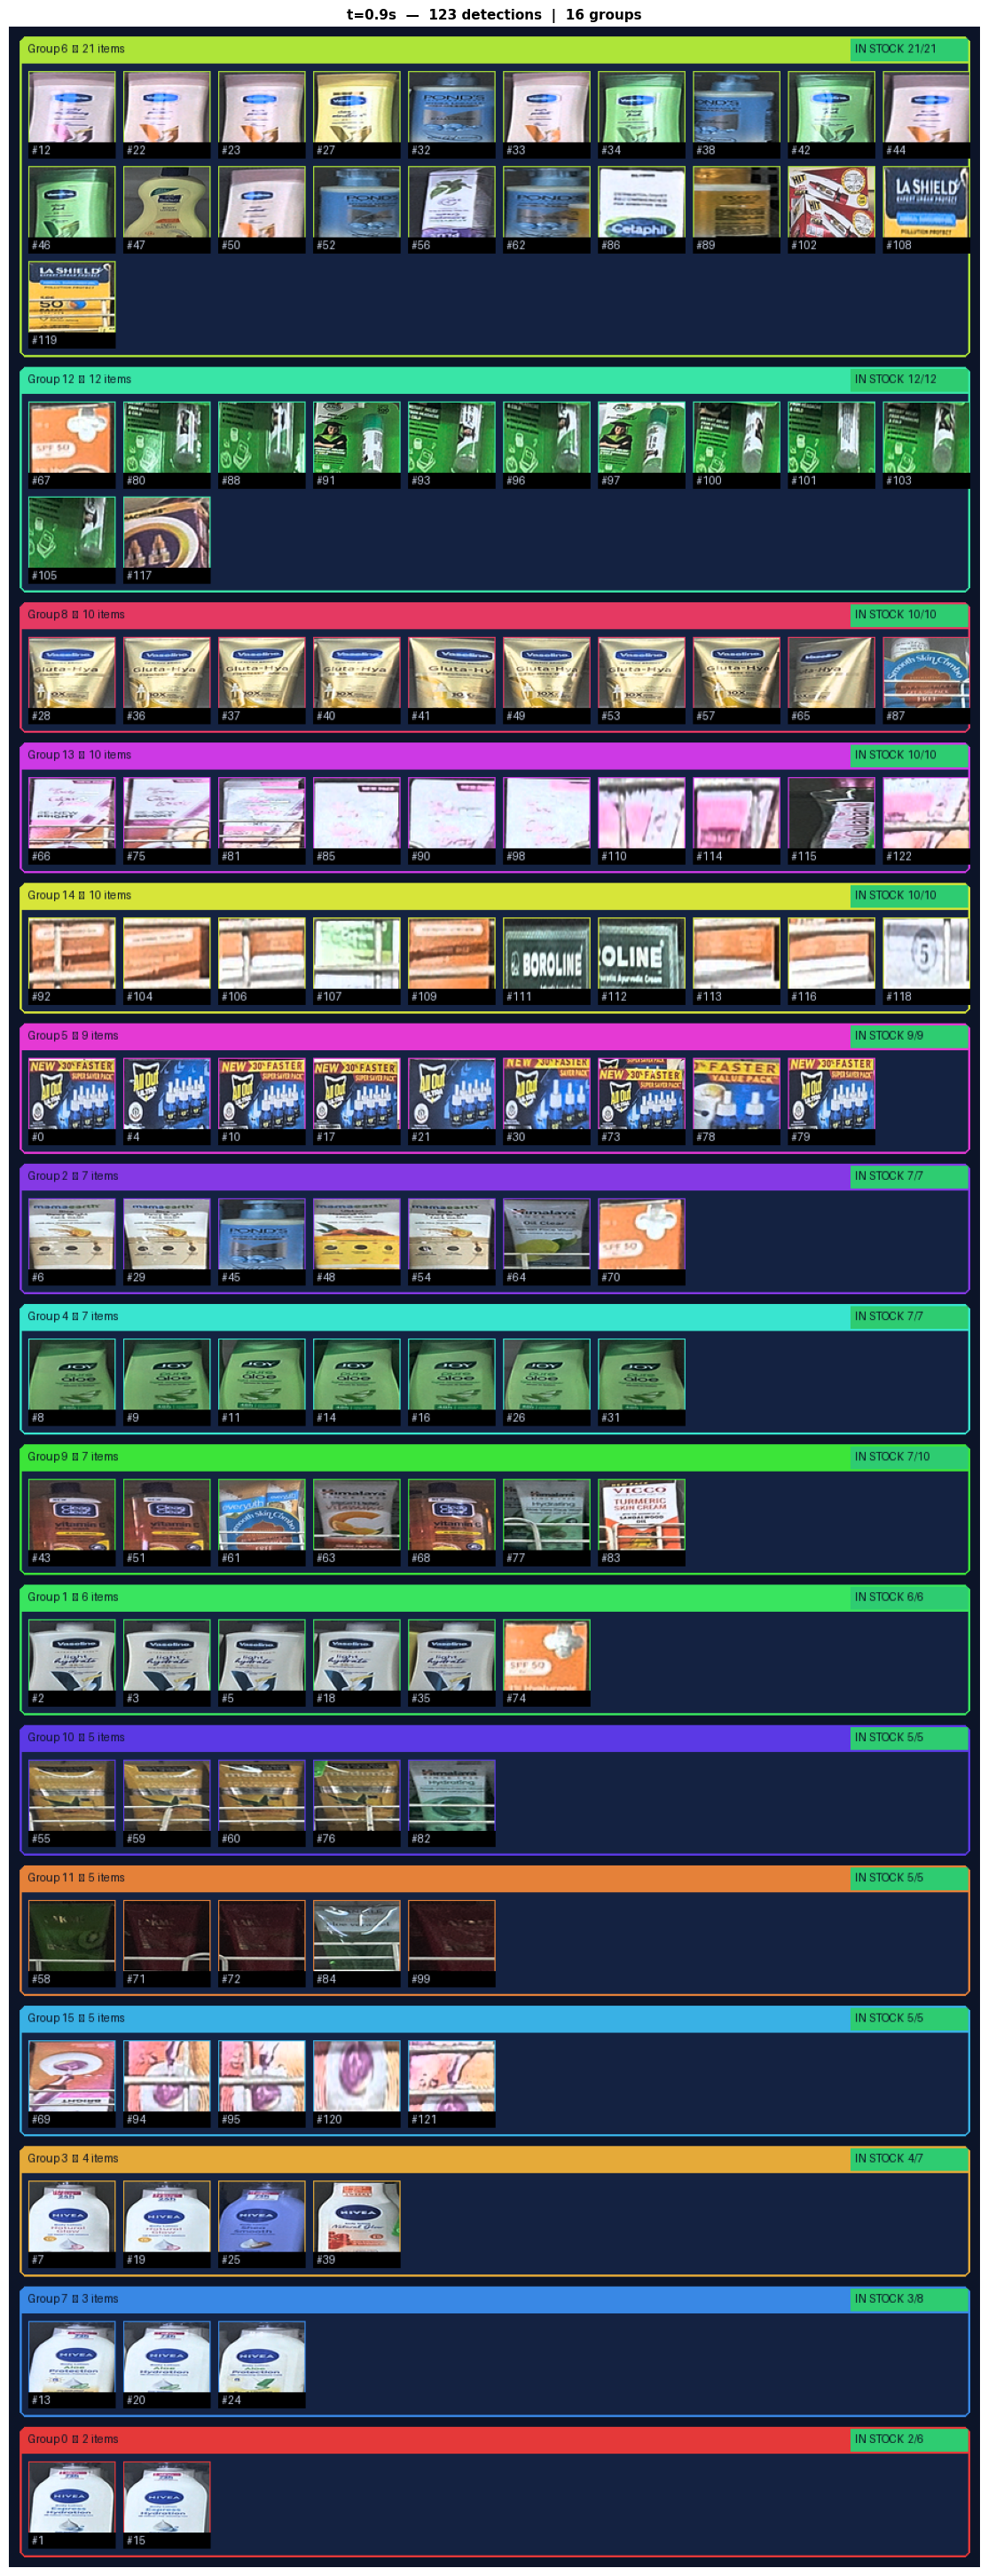

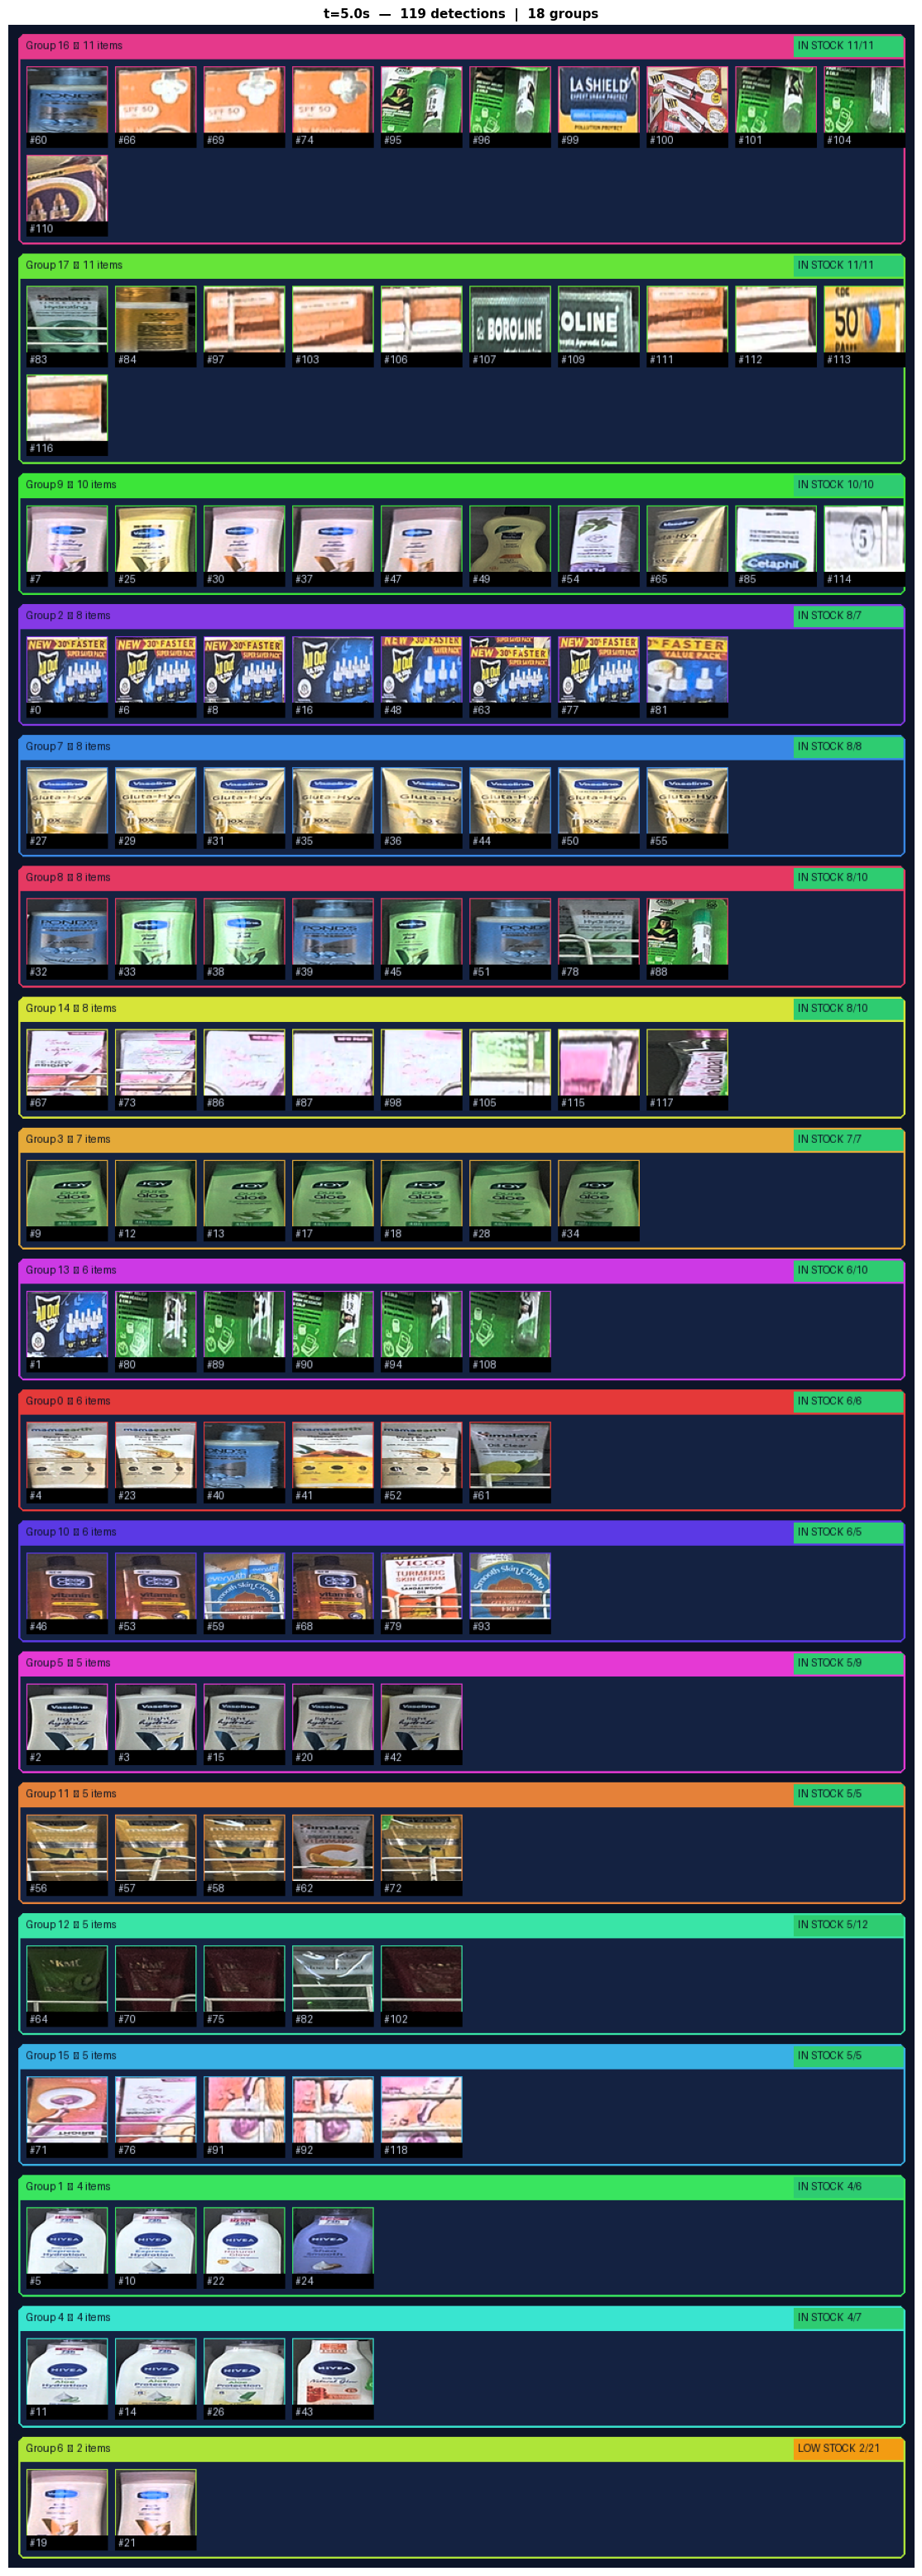

In [76]:
# ============================================================
# CELL 8C — Per-frame group gallery (styled like Cell 11)
# ============================================================

THUMB_W, THUMB_H = 80, 80
PADDING          = 8
HEADER_H         = 24
MARGIN           = 10
MAX_PER_ROW      = 10

def gid_to_rgb(gid):
    if gid == -1:
        return (150, 150, 150)
    h = (gid * 0.37) % 1.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.75, 0.90)
    return (int(r*255), int(g*255), int(b*255))

def calc_group_h(n):
    rows = math.ceil(n / MAX_PER_ROW)
    return HEADER_H + rows * (THUMB_H + PADDING) + PADDING

try:
    fnt_h = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 12)
    fnt_s = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 9)
except:
    fnt_h = fnt_s = ImageFont.load_default()

STATUS_COLORS_RGB = {
    "OUT OF STOCK" : (231, 76,  60),
    "LOW STOCK"    : (243, 156, 18),
    "IN STOCK"     : (46,  204, 113),
    "UNKNOWN"      : (149, 165, 166),
}

valid_frames = [r for r in tracker.history if not r["skipped"]]

for record in valid_frames:
    ts      = record["timestamp"]
    crops   = record["crops"]
    labels  = record["group_ids"]

    if not crops:
        print(f"t={ts:.1f}s — no detections, skipping")
        continue

    # organise by group
    groups = {}
    for i, (crop, gid) in enumerate(zip(crops, labels)):
        groups.setdefault(gid, []).append((i, crop))
    sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))

    total_h  = MARGIN + sum(calc_group_h(len(v)) + MARGIN for _, v in sorted_groups)
    canvas_w = MARGIN + MAX_PER_ROW * (THUMB_W + PADDING) + MARGIN
    canvas   = Image.new("RGB", (canvas_w, total_h), (12, 20, 40))
    draw_c   = ImageDraw.Draw(canvas)

    cursor_y = MARGIN
    for gid, items in sorted_groups:
        color  = gid_to_rgb(gid)
        status = record["stock_status"].get(gid, "UNKNOWN")
        sc     = STATUS_COLORS_RGB[status]
        base   = tracker.baseline.get(gid, "?")
        cnt    = record["group_counts"].get(gid, 0)
        gh     = calc_group_h(len(items))

        # group card background
        draw_c.rounded_rectangle(
            [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+gh],
            radius=6, fill=(20, 34, 65), outline=color, width=2
        )
        # header bar in group colour
        draw_c.rounded_rectangle(
            [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+HEADER_H],
            radius=6, fill=color
        )
        draw_c.rectangle(
            [MARGIN, cursor_y+HEADER_H//2, canvas_w-MARGIN, cursor_y+HEADER_H],
            fill=color
        )

        # status badge on right side of header
        badge_w = 110
        draw_c.rectangle(
            [canvas_w-MARGIN-badge_w, cursor_y+2,
             canvas_w-MARGIN-2,       cursor_y+HEADER_H-2],
            fill=sc
        )
        draw_c.text(
            (canvas_w-MARGIN-badge_w+4, cursor_y+5),
            f"{status}  {cnt}/{base}",
            font=fnt_s, fill=(10, 18, 35)
        )

        label_txt = (f"Group {gid}  —  {len(items)} items"
                     if gid != -1 else f"Unmatched  —  {len(items)} items")
        draw_c.text((MARGIN+8, cursor_y+5), label_txt, font=fnt_h, fill=(10, 18, 35))

        # crop thumbnails
        for idx, (orig_idx, crop) in enumerate(items):
            col   = idx % MAX_PER_ROW
            row   = idx // MAX_PER_ROW
            tx    = MARGIN + PADDING + col*(THUMB_W+PADDING)
            ty    = cursor_y + HEADER_H + PADDING + row*(THUMB_H+PADDING)
            thumb = Image.fromarray(
                        cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                    ).resize((THUMB_W, THUMB_H), Image.LANCZOS)
            canvas.paste(thumb, (tx, ty))
            draw_c.rectangle([tx, ty, tx+THUMB_W, ty+THUMB_H], outline=color, width=1)
            # index label
            draw_c.rectangle([tx, ty+THUMB_H-14, tx+THUMB_W, ty+THUMB_H], fill=(0,0,0))
            draw_c.text((tx+3, ty+THUMB_H-13), f"#{orig_idx}", font=fnt_s, fill=(200,210,230))

        cursor_y += gh + MARGIN

    # render this frame's canvas
    fig_w = canvas_w / 80
    fig_h = max(total_h / 80, 4)
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(np.array(canvas))
    plt.title(f"t={ts:.1f}s  —  {record['total_count']} detections  |  "
              f"{len(sorted_groups)} groups",
              fontsize=11, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

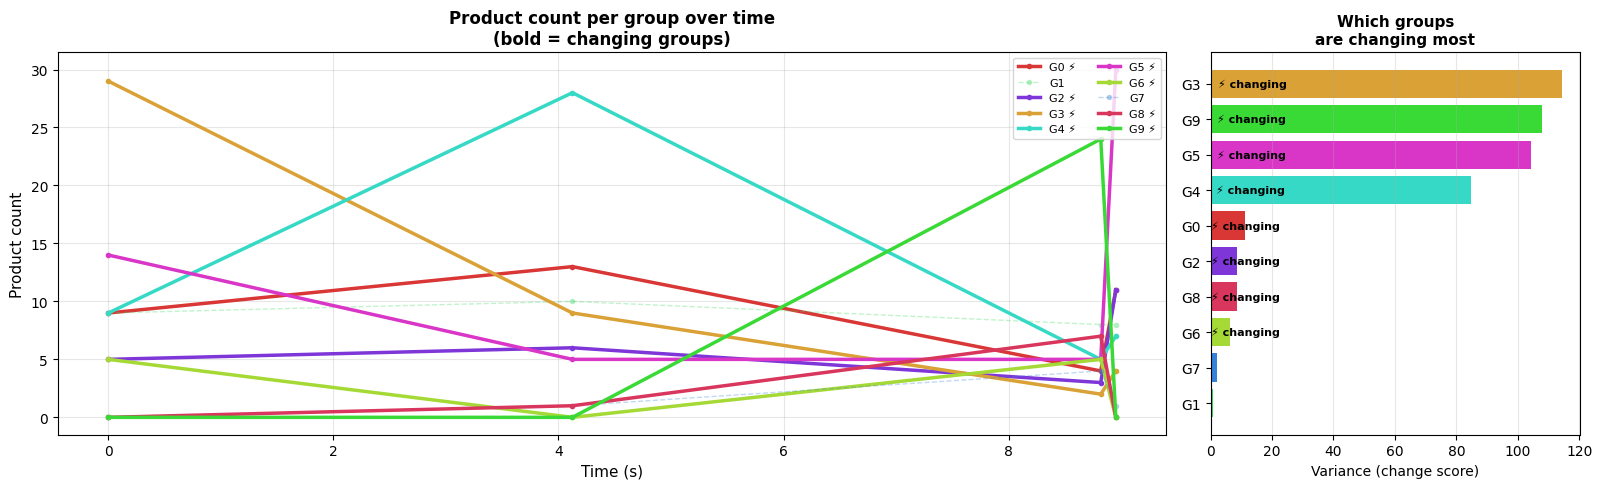


── Change summary ──────────────────────────────
  Group   3  baseline=29    variance=114.500  ⚡ CHANGING
  Group   9  baseline=24    variance=108.000  ⚡ CHANGING
  Group   5  baseline=30    variance=104.250  ⚡ CHANGING
  Group   4  baseline=28    variance=84.688  ⚡ CHANGING
  Group   0  baseline=13    variance=11.188  ⚡ CHANGING
  Group   2  baseline=11    variance=8.688  ⚡ CHANGING
  Group   8  baseline=7     variance=8.500  ⚡ CHANGING
  Group   6  baseline=5     variance=6.250  ⚡ CHANGING
  Group   7  baseline=4     variance=2.250    stable
  Group   1  baseline=9     variance=0.688    stable


In [65]:
# ============================================================
# CELL 8B — Count-change chart: which groups are changing over time
# ============================================================

def show_count_changes(tracker):
    """
    Line chart: count per group over time.
    Groups with the highest variance are highlighted — these
    are the ones whose stock is actually changing.
    """
    valid = [r for r in tracker.history if not r["skipped"]]
    if not valid:
        print("No valid frames.")
        return

    timestamps  = [r["timestamp"] for r in valid]
    all_groups  = sorted(tracker.baseline.keys())

    # build count matrix
    counts = {}
    for gid in all_groups:
        counts[gid] = [r["group_counts"].get(gid, 0) for r in valid]

    # variance per group — higher = more change
    variances = {gid: float(np.var(counts[gid])) for gid in all_groups}
    max_var   = max(variances.values()) if variances else 1
    changing  = {gid for gid, v in variances.items() if v > 0.05 * max_var}

    def gid_color(gid):
        hue = (gid * 0.37) % 1.0
        r,g,b = colorsys.hsv_to_rgb(hue, 0.75, 0.85)
        return (r,g,b)

    fig, (ax_main, ax_bar) = plt.subplots(
        1, 2, figsize=(16, 5),
        gridspec_kw={"width_ratios": [3, 1]}
    )

    # ── left: count timeline ─────────────────────────────
    for gid in all_groups:
        is_changing = gid in changing
        lw    = 2.5 if is_changing else 1.0
        alpha = 1.0 if is_changing else 0.3
        ls    = "-"  if is_changing else "--"
        color = gid_color(gid)
        ax_main.plot(timestamps, counts[gid],
                     color=color, lw=lw, alpha=alpha, ls=ls,
                     label=f"G{gid}" + (" ⚡" if is_changing else ""),
                     marker="o", markersize=3)

    ax_main.set_xlabel("Time (s)", fontsize=11)
    ax_main.set_ylabel("Product count", fontsize=11)
    ax_main.set_title("Product count per group over time\n(bold = changing groups)",
                      fontsize=12, fontweight="bold")
    ax_main.legend(loc="upper right", fontsize=8, ncol=2)
    ax_main.grid(alpha=0.3)

    # ── right: variance bar chart (change score) ─────────
    sorted_groups = sorted(all_groups, key=lambda g: variances[g], reverse=True)
    bar_colors    = [gid_color(g) for g in sorted_groups]
    bar_vals      = [variances[g] for g in sorted_groups]
    bar_labels    = [f"G{g}" for g in sorted_groups]

    bars = ax_bar.barh(bar_labels, bar_vals, color=bar_colors)
    ax_bar.set_xlabel("Variance (change score)", fontsize=10)
    ax_bar.set_title("Which groups\nare changing most", fontsize=11, fontweight="bold")
    ax_bar.invert_yaxis()
    ax_bar.grid(axis="x", alpha=0.3)

    # annotate top changers
    for bar, gid in zip(bars, sorted_groups):
        if gid in changing:
            ax_bar.text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                        "⚡ changing", va="center", fontsize=8,
                        color="black", fontweight="bold")

    plt.tight_layout()
    plt.show()

    # text summary
    print("\n── Change summary ──────────────────────────────")
    for gid in sorted_groups:
        v     = variances[gid]
        base  = tracker.baseline.get(gid, "?")
        flag  = "⚡ CHANGING" if gid in changing else "  stable"
        print(f"  Group {gid:>3}  baseline={base:<4}  variance={v:.3f}  {flag}")


show_count_changes(tracker)

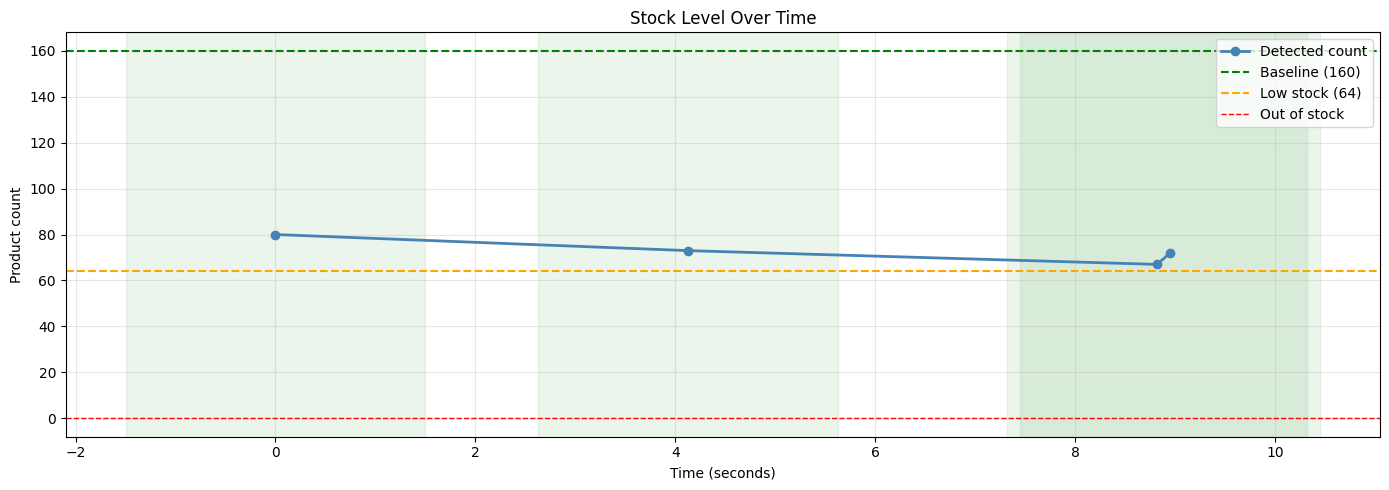

In [66]:
# ============================================================
# CELL 9 - Stock timeline chart
# ============================================================
plot_stock_timeline(tracker)

KeyError: 'frame_rgb'

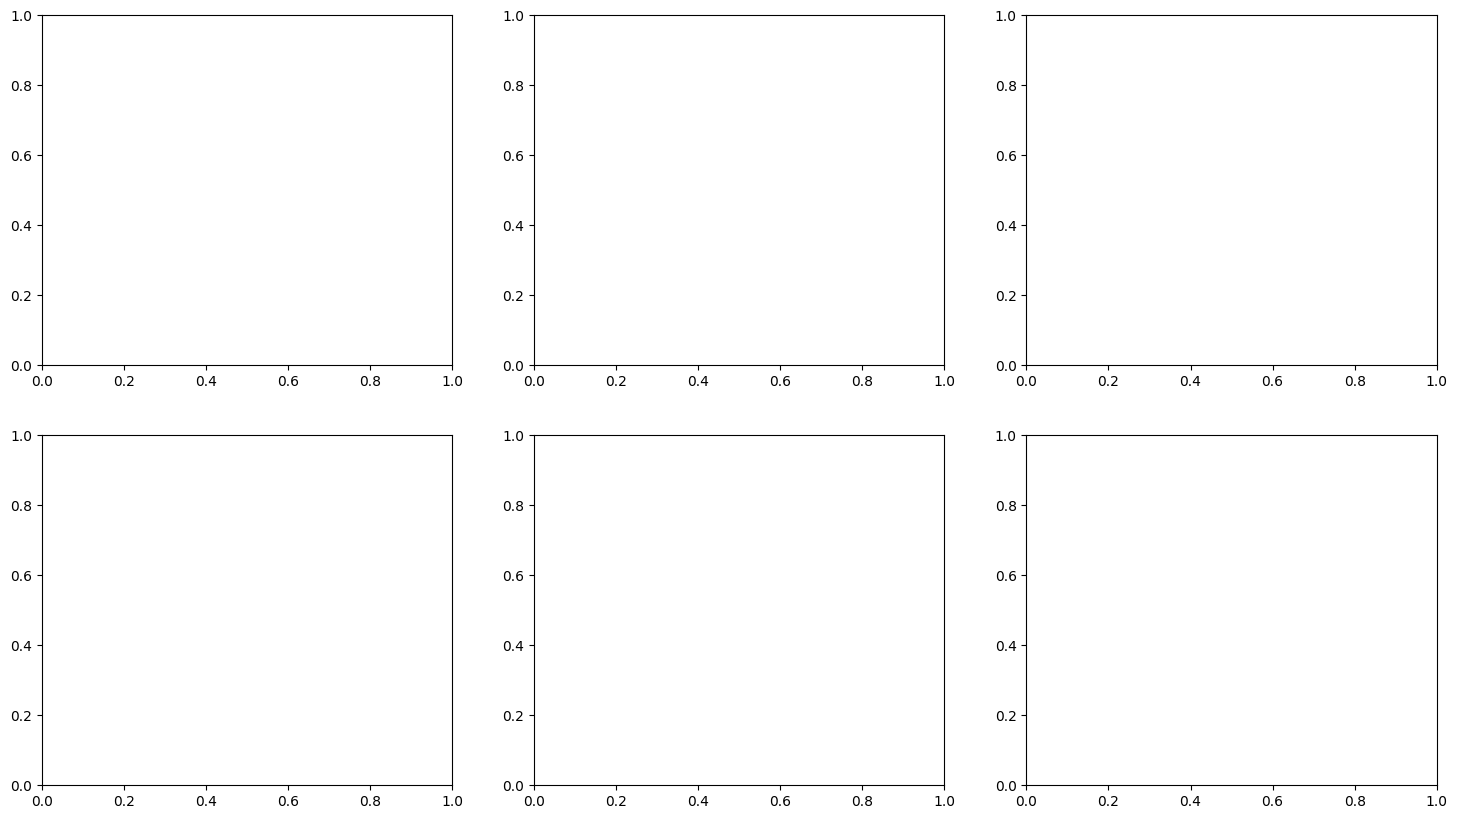

In [67]:
# ============================================================
# CELL 10 - Annotated frame grid
# ============================================================
plot_frame_grid(tracker, max_frames=9)

In [ ]:
# ============================================================
# CELL 10B - Show out-of-stock and low-stock product images
# ============================================================

# get latest valid frame's stock status
valid_frames = [r for r in tracker.history if not r["skipped"]]

if valid_frames:
    latest_status = valid_frames[-1]["stock_status"]
    show_alert_products(tracker.product_bank, latest_status, tracker)
else:
    print("No valid frames processed yet")

In [ ]:
# ============================================================
# CELL 10C - Row status summary table
# ============================================================

valid_frames = [r for r in tracker.history if not r["skipped"]]

if not valid_frames:
    print("No valid frames")
else:
    last = valid_frames[-1]
    rows = last["rows"]

    print(f"\nShelf Row Summary  (t={last['timestamp']:.1f}s)")
    print(f"{'='*55}")
    print(f"{'Row':<8} {'Products':<12} {'Status':<20}")
    print(f"{'-'*55}")

    STATUS_EMOJI = {
        "IN STOCK"    : "✅",
        "LOW STOCK"   : "⚠️ ",
        "OUT OF STOCK": "🔴",
        "UNKNOWN"     : "❓",
    }

    for row in rows:
        row_id = row["row_id"]
        status = last["row_status"].get(row_id, "UNKNOWN")
        emoji  = STATUS_EMOJI.get(status, "❓")
        n      = row["n_boxes"]
        print(f"Row {row_id+1:<4} {n:<12} {emoji} {status}")

    print(f"{'='*55}")
    print(f"Total rows detected: {len(rows)}")

    # show frame with row overlays
    annotated = draw_annotated_frame(last, tracker)
    plt.figure(figsize=(16, 8))
    plt.imshow(annotated)
    plt.title(f"Row Detection at t={last['timestamp']:.1f}s", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# CELL 11 - Inspect a specific frame in detail
# ============================================================
FRAME_INDEX = 0  # change to any valid frame index

valid_frames = [r for r in tracker.history if not r["skipped"]]

if FRAME_INDEX < len(valid_frames):
    result    = valid_frames[FRAME_INDEX]
    annotated = draw_annotated_frame(result, tracker)

    plt.figure(figsize=(16, 8))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(f"Frame at t={result['timestamp']:.1f}s", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\nFrame details:")
    print(f"  Timestamp   : {result['timestamp']:.1f}s")
    print(f"  Total count : {result['total_count']}")
    print(f"\n  Group breakdown:")
    for gid, cnt in result["group_counts"].items():
        base   = tracker.baseline.get(gid, "?")
        status = result["stock_status"].get(gid, "UNKNOWN")
        color  = {"IN STOCK":"✅", "LOW STOCK":"⚠️", "OUT OF STOCK":"🔴"}.get(status, "❓")
        print(f"    {color} Group {gid}: {cnt}/{base}  →  {status}")
else:
    print(f"Only {len(valid_frames)} valid frames available")

In [ ]:
# ============================================================
# CELL 12 - Save full report as JSON
# ============================================================
report = {
    "baseline"     : tracker.baseline,
    "total_frames" : tracker.frame_no,
    "valid_frames" : len([r for r in tracker.history if not r["skipped"]]),
    "skipped_frames": len([r for r in tracker.history if r["skipped"]]),
    "timeline"     : [
        {
            "frame_no"    : r["frame_no"],
            "timestamp"   : round(r["timestamp"], 2),
            "skipped"     : r["skipped"],
            "skip_reason" : r["skip_reason"],
            "total_count" : r["total_count"],
            "group_counts": r["group_counts"],
            "stock_status": r["stock_status"],
        }
        for r in tracker.history
    ]
}

REPORT_PATH = "/content/drive/MyDrive/stock_report.json"
with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)

print(f"Report saved to {REPORT_PATH}")